TP Analisis de jupyter

In [12]:
import pandas as pd

In [13]:
import plotly.express as px

fig = px.bar()

In [14]:
import folium

def generar_mapa():
    attr = (
        '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> '
        'contributors, &copy; <a href="https://cartodb.com/attributions">CartoDB</a>'
    )
    
    tiles = 'https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png'
    m = folium.Map(
        location=(-33.457606, -65.346857),
        control_scale=True,
        zoom_start=5,
        name='es',
        tiles=tiles,
        attr=attr
    )
    return m

    mapa = generar_mapa()

In [15]:
aeropuertos = pd.read_csv("ar-airports.csv")

1) Informacion General

In [3]:
print(aeropuertos["type"].value_counts())

type
small_airport     694
heliport          148
medium_airport     69
closed             42
large_airport       2
balloonport         1
Name: count, dtype: int64


2) Frecuencia

In [4]:
print(aeropuertos["type"].value_counts())
print(aeropuertos["region_name"].value_counts())

type
small_airport     694
heliport          148
medium_airport     69
closed             42
large_airport       2
balloonport         1
Name: count, dtype: int64
region_name
Buenos Aires Province             268
Córdoba Province                  100
Santa Fe Province                  97
Santa Cruz Province                75
Entre Ríos Province                44
Chubut Province                    41
Corrientes Province                35
Río Negro Province                 32
Neuquén Province                   31
La Pampa Province                  29
Salta Province                     26
Tierra del Fuego Province          24
Mendoza Province                   23
Santiago del Estero Province       22
Chaco Province                     20
Misiones Province                  16
Buenos Aires (Autonomous City)     14
Formosa Province                   12
San Luis Province                  12
Catamarca Province                  9
Tucumán Province                    8
Jujuy Province             

Respuesta: El tipo de aeropuerto mas comun es el aeropuerto chico y la provincia con mas aeropuertos es Buenos Aires con 268

3) Filtros

In [5]:
filtro = aeropuertos[aeropuertos["region_name"] == "Buenos Aires Province"]

In [7]:
filtro

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,country_name,iso_country,...,scheduled_service,gps_code,icao_code,iata_code,local_code,home_link,wikipedia_link,keywords,score,last_updated
0,5781,SAEZ,large_airport,Minister Pistarini International Airport,-34.822200,-58.535800,67.0,SA,Argentina,AR,...,1,SAEZ,SAEZ,EZE,EZE,http://www.aa2000.com.ar/index.php,https://en.wikipedia.org/wiki/Ministro_Pistari...,"BUE, Ezeiza",1275,2022-10-27T15:05:29+00:00
11,5775,SADF,medium_airport,San Fernando Airport,-34.453200,-58.589600,10.0,SA,Argentina,AR,...,0,SADF,NaN,NaN,FDO,NaN,https://en.wikipedia.org/wiki/San_Fernando_Air...,San Fernando International Airport,250,2022-01-23T12:53:12+00:00
17,5847,SAZM,medium_airport,Ástor Piazzola International Airport,-37.934200,-57.573300,72.0,SA,Argentina,AR,...,1,SAZM,SAZM,MDQ,MDP,NaN,https://en.wikipedia.org/wiki/%C3%81stor_Piazz...,Brigadier General Bartolome De La Colina Inter...,750,2011-02-13T00:27:06+00:00
20,5840,SAZB,medium_airport,Comandante Espora Airport,-38.725000,-62.169300,246.0,SA,Argentina,AR,...,1,SAZB,SAZB,BHI,BCA,https://www.aeropuertobahiablanca.com/,https://en.wikipedia.org/wiki/Comandante_Espor...,Bahía Blanca Airport,750,2025-03-19T03:18:32+00:00
24,5780,SADP,medium_airport,El Palomar Airport,-34.609900,-58.612600,59.0,SA,Argentina,AR,...,0,SADP,SADP,EPA,PAL,NaN,https://en.wikipedia.org/wiki/El_Palomar_Airport,NaN,300,2022-01-23T16:28:39+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,351892,AR-0731,heliport,San Fernando / Paraná Miní Heliport,-34.171068,-58.510855,16.0,SA,Argentina,AR,...,0,NaN,NaN,NaN,HMH,NaN,NaN,NaN,0,2022-01-24T18:38:44+00:00
943,42899,AR-0477,heliport,Metalúrgico / Miguel Colombise Heliport,-33.358949,-60.249377,88.0,SA,Argentina,AR,...,0,NaN,NaN,NaN,HSN,NaN,NaN,NaN,0,2022-01-24T22:05:57+00:00
948,42895,AR-0473,heliport,Estancia La Pascuala Heliport,-37.393600,-58.966100,721.0,SA,Argentina,AR,...,0,NaN,NaN,NaN,HTD,NaN,NaN,NaN,0,2009-10-20T11:13:21+00:00
949,318517,AR-0578,heliport,Villa La Ñata Heliport,-34.375270,-58.655760,10.0,SA,Argentina,AR,...,0,NaN,NaN,NaN,HVA,NaN,NaN,NaN,0,2016-06-12T11:39:32+00:00


Respuesta: son 268 aeropuertos en Buenos Aires

4) Calculo

In [8]:
filtro = aeropuertos[aeropuertos["type"] == "large_airport"]
filtro2 = aeropuertos[aeropuertos["type"] == "small_airport"]
print(filtro["elevation_ft"].mean())
print(filtro2["elevation_ft"].mean())

42.5
805.7620481927711


Respuesta: la elevacion promedio de los aeropuertos largos es 42 y la de los chicos es 805

5) Grafico

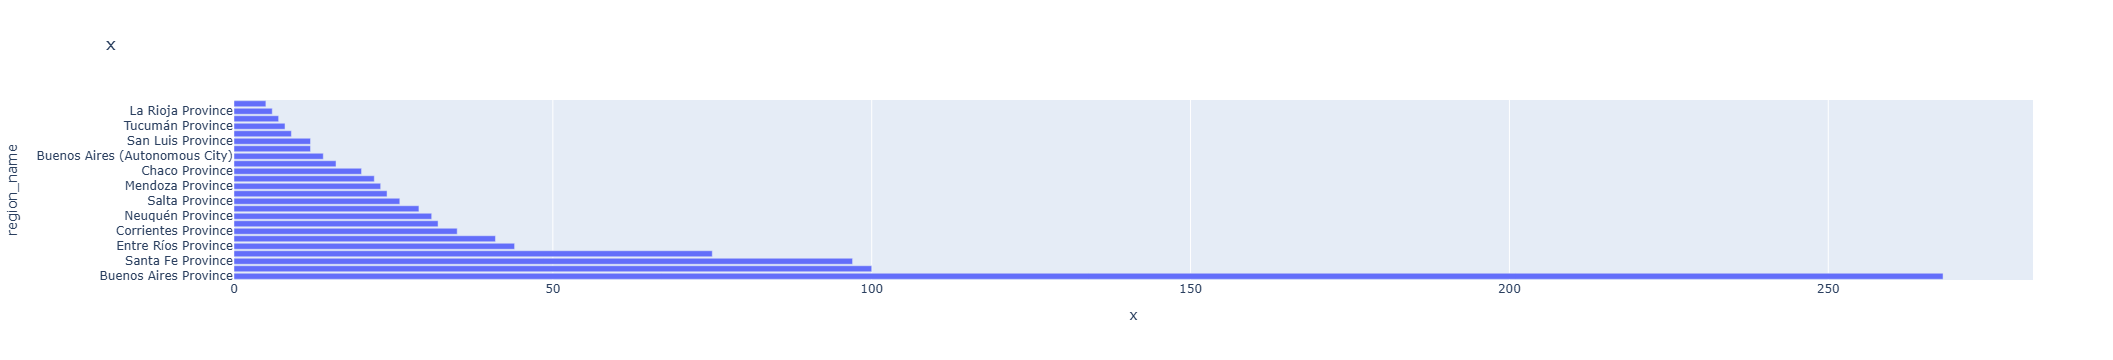

In [13]:
grafico = aeropuertos["region_name"].value_counts()
px.bar(data_frame = grafico, x = grafico.values, y = grafico.index, title = "x").show()

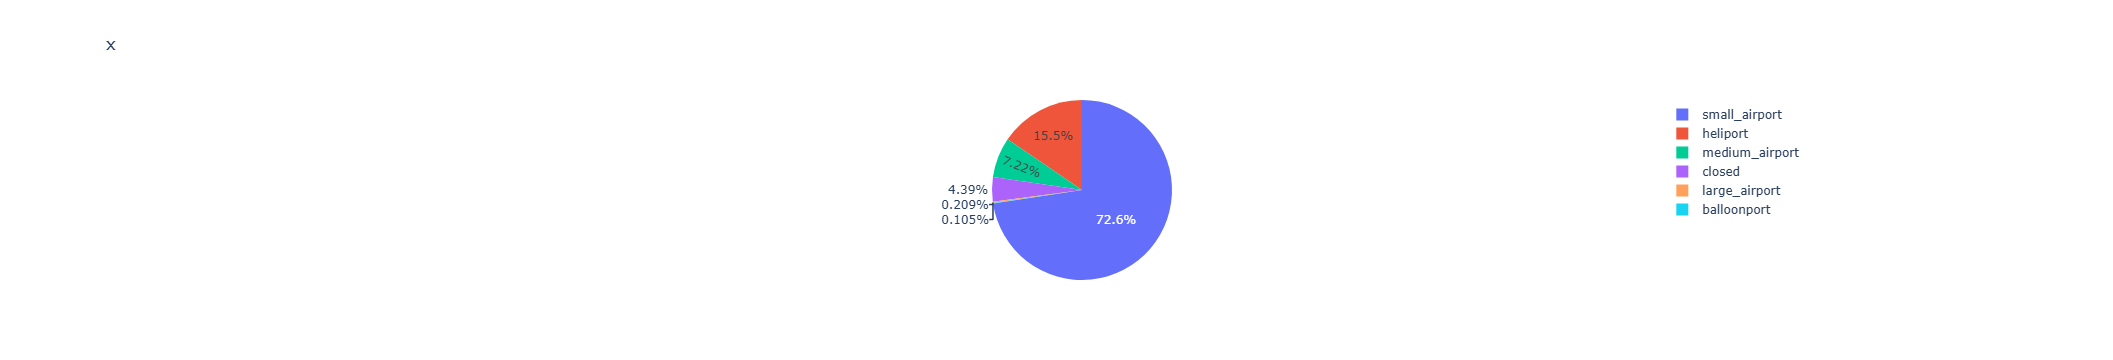

In [14]:
grafico = aeropuertos["type"].value_counts()
px.pie(data_frame = grafico, values = grafico.values, names = grafico.index, title = "x").show()

6) Mapa

In [20]:
def generar_mapa():
    attr = (
        '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> '
        'contributors, &copy; <a href="https://cartodb.com/attributions">CartoDB</a>'
    )
    
    tiles = 'https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png'
    m = folium.Map(
        location=(-33.457606, -65.346857),
        control_scale=True,
        zoom_start=5,
        name='es',
        tiles=tiles,
        attr=attr
    )
    return m

mapa = generar_mapa()

filtro = aeropuertos[aeropuertos["type"] == "closed"]
def agregar_marca_lago(row):
    colores = {"Buenos Aires Province": "blue",
    "Córdoba Province": "red",
    "Santa Fe Province": "green",
    "Santa Cruz Province": "purple",
    "Entre Ríos Province": "orange",
    "Chubut Province": "darkred",
    "Corrientes Province": "lightred",
    "Río Negro Province": "beige",
    "Neuquén Province": "darkblue",
    "La Pampa Province": "darkgreen",
    "Salta Province": "cadetblue",
    "Tierra del Fuego Province": "darkpurple",
    "Mendoza Province": "pink",
    "Santiago del Estero Province": "lightblue",
    "Chaco Province": "lightgreen",
    "Misiones Province": "gray",
    "Buenos Aires (Autonomous City)": "black",
    "Formosa Province": "lightgray",
    "San Luis Province": "blue",
    "Catamarca Province": "red",
    "Tucumán Province": "green",
    "Jujuy Province": "purple",
    "La Rioja Province": "orange",
    "San Juan Province": "darkblue"}
    color = colores.get(row['region_name'], 'gray')
    folium.CircleMarker( 
        location=[row['latitude_deg'], row['longitude_deg']],
        radius=6,
        color=color,
        fill=True,
        popup=row['name']
        ).add_to(mapa)

filtro.apply(agregar_marca_lago, axis=1)
mapa